Dependencies (might be incomplete)

Using conda (conda install (-c conda-forge) \*name\*):
- esgf-pyclient
- xarray
- cartopy
- matplotlib
- geopandas
- numpy
- pandas
- dask
- cftime
- rioxarray
- pydap
- statsmodels

using pip (*path/to/pip/in/conda/env*/pip/install *name*):
- quantile-forest

In [1]:
from pyesgf.search import SearchConnection
import xarray as xr
import cartopy.crs as ccrs
from cartopy import io
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
from datetime import datetime as dt
import re
import os
import geopandas as gpd
import warnings
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import dask
from tools import result_to_dict, load_datasets, get_obs_data, get_distance, clip
import logging
from quantile_forest import RandomForestQuantileRegressor
from statsmodels.tsa.seasonal import seasonal_decompose



# Needs also  rioxarray

import rioxarray

In [2]:
# Example nodes. Due to outages, you may need to change the address in SearchConnection.
# Also note that sometimes (quite often), there will be problems with using ESGF this way.
# One way to circumvent the problems is to download the actual files manually. If this way is used, you can just
# from tools import process
# ds = xr.open_mfdataset([ds_files],preprocess=lambda ds: process(ds,var,min_date,max_date))
# to make sure that the format is correct
# Then simply add them do a dictionary (dsets[model_name]=dset) for each

#https://esgf-node.llnl.gov/esg-search
#https://esgf.ceda.ac.uk/esg-search
#https://esgf-data.dkrz.de/esg-search #does not inlude all models

In [3]:
# Connect to ESGF
#conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)
conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib=True)


# Turn off warnings (generally not advisible but here it makes sense)
os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "0"
warnings.simplefilter("ignore")
logging.getLogger('distributed').setLevel(logging.WARNING)

In [4]:
# Temporal limits of the data
min_date = dt(1980,1,1)
max_date = dt(2024,12,31)
# Parameters for seaching
var = "tas"
exp = "historical"
tbl = "Amon"
variant = "r1i1p1f1"
source_id = ["ACCESS-CM2",
            "MIROC6",
            "CESM2-WACCM-FV2",
            "EC-Earth3-AerChem",
            "GISS-E2-2-H",
            "NorESM2-MM"]


# Search for matches
ctx = conn.new_context(
table_id = tbl,
experiment_id = exp,
variant_label = variant,
variable_id = var,
source_id = source_id,
latest = "true"
)
# Check if matches found
if ctx.hit_count == 0:
    print("No datasets found")
    raise SystemExit()
else:
    # If yes, print number of matches and get matches
    print(ctx.hit_count)
    result = ctx.search()

29


In [5]:
# Downloads the required shapefile (if not already downloaded)
fname = io.shapereader.natural_earth(
    resolution='10m', 
    category='cultural',
    name='admin_0_countries')
geodf = gpd.read_file(fname,crs="epsg:4326")
# Shapefile and CMIP6 should both have the same coordinate reference system (crs)
crs = geodf.crs

In [6]:
result_dict_model = result_to_dict(result)

In [7]:
res = {key:load_datasets((key,value),var,min_date,max_date) for key,value in result_dict_model.items()}
del result_dict_model

In [8]:
# Excecute loading. Cluster parameters can be altered to fit the system.
# Note: this part does fail quite often due to ESGF. Consider trying other nodes and/or waiting
# UnboundLocalError: cannot access local variable 'dsets_c' where it is not associated with a value -> some datasets couldn't be accessed

cluster = LocalCluster(n_workers=6,threads_per_worker=1,memory_limit="2GiB")
client = Client(cluster)
print(client.dashboard_link)
dsets = dask.compute(res)[0]
del res
client.close()
cluster.close()
del client
del cluster

http://127.0.0.1:8787/status


Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Note:Caching=1
Note:Caching=1
Note:Caching=1
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Note:Caching=1
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 
Note:Caching=1
Error:curl erro

Successfully opened CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1i1p1f1.Amon.tas.gn.v20191108 1
Successfully opened CMIP6.CMIP.NASA-GISS.GISS-E2-2-H.historical.r1i1p1f1.Amon.tas.gn.v20191120 2
Successfully opened CMIP6.CMIP.MIROC.MIROC6.historical.r1i1p1f1.Amon.tas.gn.v20181212 1
Successfully opened CMIP6.CMIP.NCC.NorESM2-MM.historical.r1i1p1f1.Amon.tas.gn.v20191108 4
Successfully opened CMIP6.CMIP.EC-Earth-Consortium.EC-Earth3-AerChem.historical.r1i1p1f1.Amon.tas.gr.v20200624 35
Successfully opened CMIP6.CMIP.NCAR.CESM2-WACCM-FV2.historical.r1i1p1f1.Amon.tas.gn.v20191120 2


In [9]:
for model, value in dsets.items():
    # Some models deviate from the standars date, this should fix that
    if pd.to_datetime(value["time"].time.values[0]).day == 15:
        dsets[model]["time"] = value["time"]+np.timedelta64(1,"D")
    dsets[model]["time"] = pd.DatetimeIndex(dsets[model]["time"])


In [10]:
###OBSERVATIONS###

In [11]:
# Quality Control, Adjusted, using the Pairwise Homogeneity Algorithm (PHA, Menne and Williams, 2009), see: https://www.ncei.noaa.gov/pub/data/ghcn/v4/ and the readme.txt in it
url = "https://www.ncei.noaa.gov/pub/data/ghcn/v4/ghcnm.tavg.latest.qcf.tar.gz"
df_filtered = get_obs_data(url)

In [12]:
# Get columns that have values
value_cols = list(filter(lambda x: x.startswith("VALUE"),df_filtered.columns))

In [13]:
# Reset index to enable melt
df_filtered = df_filtered.reset_index(names=["ID"])

# Reshape the data DataFrame to split months to their own columns
df_values = df_filtered.melt(id_vars=["ID","YEAR","longitude","latitude","elevation"], value_vars=value_cols, var_name="Month", value_name="tas")

# Extract month from value (e.g. VALUE5 -> 5)
df_values["Month"] = df_values["Month"].apply(lambda x: re.sub(r"VALUE([0-9]{1,2})",r"\g<1>",x))

# Create a date column and drop month and year ("time" is chosen as the name to match CMIP6)
df_values["time"] = pd.to_datetime(df_values["YEAR"].astype(str) + "-" + df_values["Month"].astype(str) + "-15")
df_values = df_values.drop(["YEAR","Month","ID"],axis=1)

# Drop rows that don't have data
df_cleaned = df_values.dropna(how="any",axis=0)

# Limit temporally to the historical CMIP6 era
df_limited = df_cleaned.loc[(df_cleaned["time"]>=pd.to_datetime("1980-01-01")) & (df_cleaned["time"]<=pd.to_datetime("2014-12-31"))].reset_index(drop=True)

# Average tas and evelation where several measurements exist in a single location
df_limited = df_limited.groupby(["time", "longitude", "latitude"])[["tas","elevation"]].mean().reset_index()

# Drop missing values
df_limited = df_limited.drop(df_limited[df_limited["tas"]==-9999].index,axis=0)

# Transform temperature (e.g., 560 -> 5.6 C)
df_limited["tas"] /= 100

# Split time column into year and month for interpolation purposes
df_limited["month"] = df_limited["time"].dt.month
df_limited["year"] = df_limited["time"].dt.year

del df_cleaned
del df_filtered

In [14]:
# Define the grid for interpolation
X, Y = np.mgrid[np.min(df_limited["longitude"])-0.5:np.max(df_limited["longitude"])+1:0.5,
            np.min(df_limited["latitude"])-0.5:np.max(df_limited["latitude"])+0.5:0.5]

In [15]:
# Two nearly identical sources for elevation data

# RM remove not working url
#elevation_urls = ["https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO1_Bed_g_gmt4.nc"]
#elevation_urls = ["https://www.ngdc.noaa.gov/mgg/global/relief/ETOPO1/thredds/ETOPO1_Bed_g_gmt4.nc"]
elevation_urls = ["/home/makkoner/Downloads/ETOPO1_Bed_g_gmt4.nc"]

#elevation_urls = ["https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO1_Bed_g_gmt4.nc","https://pae-paha.pacioos.hawaii.edu/thredds/dodsC/srtm30plus_v11_land"]

In [16]:
ds = xr.open_dataset("https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO1_Bed_g_gmt4.nc")

Error:curl error: Problem with the SSL CA cert (path? access rights?)
curl error details: 


OSError: [Errno -68] NetCDF: I/O failure: b'https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO1_Bed_g_gmt4.nc'

In [17]:
cluster = LocalCluster(n_workers=30)
client = Client(cluster)
print(client.dashboard_link)
try:
    # Primary source (quicker but sometimes doesn't work)
    #print(---) # <- uncomment to force the back-up source
    ds = xr.open_dataset(elevation_urls[0],chunks={"lon":500,"lat":500})
    elev = ds.z.sel({"lon":np.unique(X),"lat":np.unique(Y)},method="nearest").load()
except:
    client.close()
    cluster.close()
    del cluster
    del client
    # Back-up source
    print("Trying the back-up source")
    cluster = LocalCluster(n_workers=30)
    client = Client(cluster)
    print(client.dashboard_link)
    ds = xr.open_dataset(elevation_urls[1],chunks={"lat":1000,"lon":1000})
    elev = ds.elev.sel({"lon":np.unique(X),"lat":np.unique(Y)},method="nearest").load()
client.close()
cluster.close()
del client
del cluster

http://127.0.0.1:8787/status


In [18]:
# Convert the DataArray to a DataFrame
elev_df = elev.to_pandas().reset_index().melt(id_vars=['lat'], var_name='lon', value_name='elevation').sort_values(by="lat").rename({"lat":"latitude","lon":"longitude"},axis=1)
elev_df["longitude"] = elev_df["longitude"].astype(np.float64)
elev_df = elev_df.fillna(0)
del elev

In [19]:
# Distance to ocean from each point
df_limited = get_distance(df_limited)
elev_df = get_distance(elev_df)

In [20]:
# Construct and fit a ramdom forest for interpolation
# Using QuantileRegressor intead of the regular provides use with an uncertainty estimate
forest = RandomForestQuantileRegressor(n_jobs=-1).fit(df_limited[["longitude","latitude","distance","elevation","month","year"]],df_limited["tas"])

In [21]:
# Unique times (used for making the interpolation process less-RAM heavy)
times = sorted(df_limited["time"].unique())
# Corodinates are used to reshape the prediction
lons = elev_df["longitude"].unique()
lats = elev_df["latitude"].unique()
# Initialize result arrays
median = np.zeros([len(lats),len(lons),len(times)])
f_quantile = np.zeros([len(lats),len(lons),len(times)])
l_quantile = np.zeros([len(lats),len(lons),len(times)])

In [22]:
for idx, time in enumerate(times):
    # Insert a constant-value month and year to the time-independent DataFrame
    elev_df2 = elev_df.copy()
    elev_df2["month"] = time.month
    elev_df2["year"] = time.year
    # Predict (quantiles = 2.5%, 50% and 97.5%)
    prediction = forest.predict(elev_df2[["longitude","latitude","distance","elevation","month","year"]],quantiles=[0.025, 0.5, 0.975])
    # Sort the predictions based on the coordinates
    sorted_indices = np.lexsort((elev_df["longitude"], elev_df["latitude"]))
    sorted_prediction =  prediction[sorted_indices]
    # Record the results
    median[:,:,idx] = sorted_prediction[:,1].reshape(len(lats),len(lons))
    f_quantile[:,:,idx] = sorted_prediction[:,0].reshape(len(lats),len(lons))
    l_quantile[:,:,idx] = sorted_prediction[:,2].reshape(len(lats),len(lons))
del forest

In [23]:
# turn the result into a Dataset
obs_ds = xr.Dataset(data_vars={"tas":(["lat","lon","time"],median),"Q2.5":(["lat","lon","time"],f_quantile),"Q97.5":(["lat","lon","time"],l_quantile)},coords={"time":(["time"],np.unique(df_limited["time"])),"lon":(["lon"],np.unique(elev_df["longitude"])),"lat":(["lat"],np.unique(elev_df["latitude"]))})

In [24]:
country_list = []
for country in geodf[geodf["CONTINENT"]=="Africa"]["NAME"]:
    # Extract geometry
    country_geom = geodf[geodf["NAME"]==country].geometry
    country_list.append(country_geom)
from shapely.ops import unary_union
# Combine MultiPolygons to create the African continent
area_geometries = unary_union(country_list)

In [25]:
# Cut data outside of Africa
clipped_models = {key: clip(value,area_geometries,crs) for key,value in dsets.items()}
clipped_models["obs"] = clip(obs_ds,area_geometries,crs)

In [26]:
cluster = LocalCluster(n_workers=2,threads_per_worker=1,memory_limit="3GiB")
client = Client(cluster)
print(client.dashboard_link)
clipped_models = dask.compute(clipped_models)[0]
client.close()
cluster.close()

http://127.0.0.1:8787/status


In [27]:
# Create a timeseries
timeseries = {key:value.mean(["lat","lon"])-273.15 for key,value in clipped_models.items()}
timeseries[list(timeseries.keys())[-1]] += 273.15

In [28]:
keys = list(timeseries.keys())

In [29]:
# Decompose into trend, seasonal and residual -> seasonal is not included in the analysis
stationary0 = seasonal_decompose(timeseries[keys[0]]["tas"].values,period=12)
stationary1 = seasonal_decompose(timeseries[keys[1]]["tas"].values,period=12)
stationary2 = seasonal_decompose(timeseries[keys[2]]["tas"].values,period=12)
stationary3 = seasonal_decompose(timeseries[keys[3]]["tas"].values,period=12)
stationary4 = seasonal_decompose(timeseries[keys[4]]["tas"].values,period=12)
stationary5 = seasonal_decompose(timeseries[keys[5]]["tas"].values,period=12)
stationary6 = seasonal_decompose(timeseries[keys[6]]["tas"].values,period=12) # observations
stationary7 = seasonal_decompose(timeseries[keys[6]]["Q2.5"].values,period=12) 
stationary8 = seasonal_decompose(timeseries[keys[6]]["Q97.5"].values,period=12)

Text(0.5, 0.98, 'Near-Surface Air Temperatures over Africa')

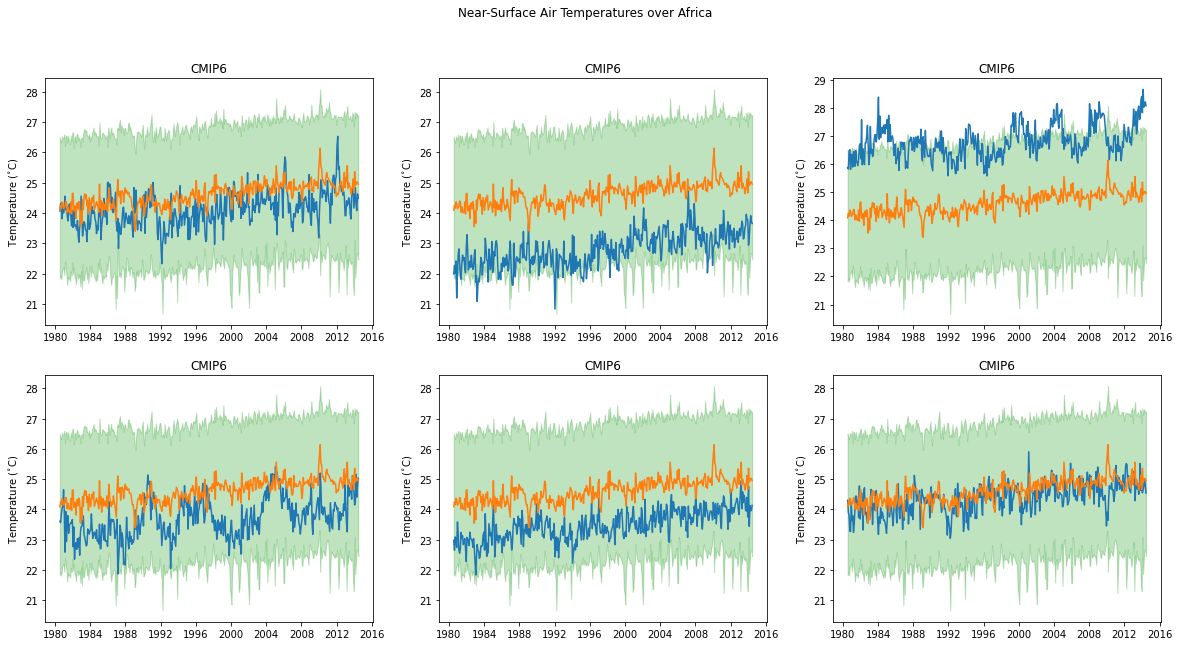

In [30]:
fig, axis = plt.subplots(2,3,figsize=(20,10))
labels = [re.findall(r"[^\.]*",key)[0] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary0.trend+stationary0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary6.trend+stationary6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary1.trend+stationary1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary6.trend+stationary6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary2.trend+stationary2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary6.trend+stationary6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary3.trend+stationary3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary6.trend+stationary6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary4.trend+stationary4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary6.trend+stationary6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary5.trend+stationary5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary6.trend+stationary6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary7.trend+stationary7.resid,stationary8.trend+stationary8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over Africa")

Text(0.5, 0.98, 'Near-Surface Air Temperatures over Ghana')

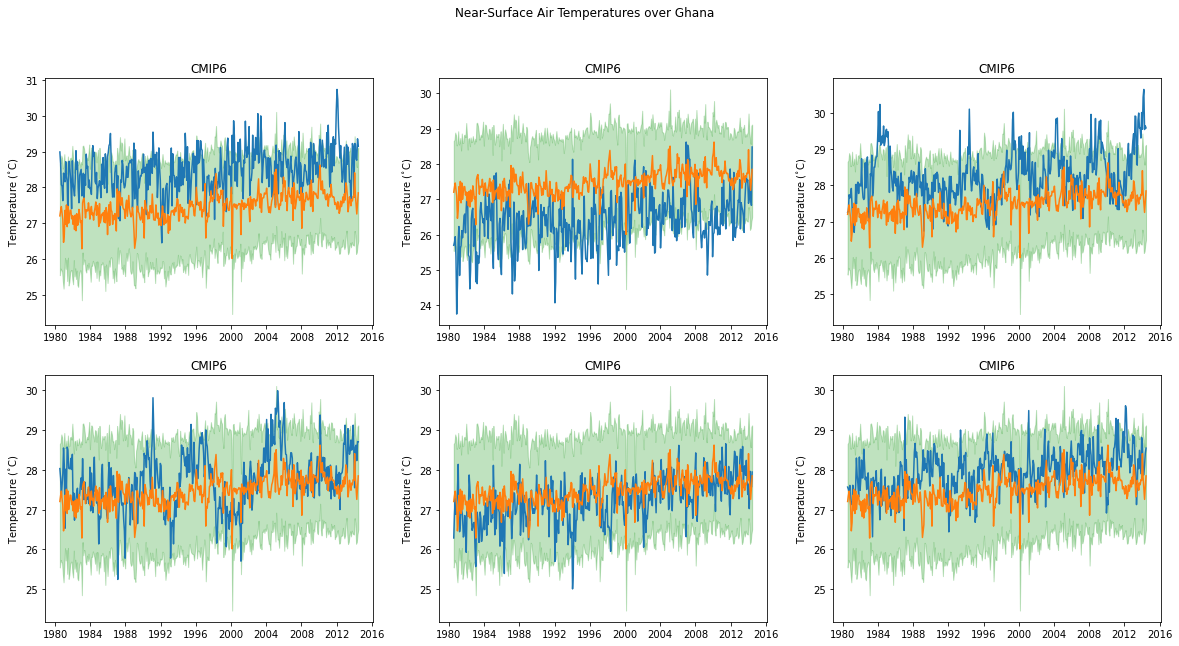

In [31]:
ghana = geodf[geodf["NAME"]=="Ghana"]["geometry"]
ghana_tasks = {key:clip(value,ghana,crs) for key,value in clipped_models.items()}
ghana_clipped = dask.compute(ghana_tasks)[0]


timeseries_ghana = {key:value.mean(["lat","lon"])-273.15 for key,value in ghana_clipped.items()}
timeseries_ghana[list(timeseries_ghana.keys())[-1]] += 273.15

stationary_ghana0 = seasonal_decompose(timeseries_ghana[keys[0]]["tas"].values,period=12)
stationary_ghana1 = seasonal_decompose(timeseries_ghana[keys[1]]["tas"].values,period=12)
stationary_ghana2 = seasonal_decompose(timeseries_ghana[keys[2]]["tas"].values,period=12)
stationary_ghana3 = seasonal_decompose(timeseries_ghana[keys[3]]["tas"].values,period=12)
stationary_ghana4 = seasonal_decompose(timeseries_ghana[keys[4]]["tas"].values,period=12)
stationary_ghana5 = seasonal_decompose(timeseries_ghana[keys[5]]["tas"].values,period=12)
stationary_ghana6 = seasonal_decompose(timeseries_ghana[keys[6]]["tas"].values,period=12) # observations
stationary_ghana7 = seasonal_decompose(timeseries_ghana[keys[6]]["Q2.5"].values,period=12)
stationary_ghana8 = seasonal_decompose(timeseries_ghana[keys[6]]["Q97.5"].values,period=12)

fig, axis = plt.subplots(2,3,figsize=(20,10))
keys = list(timeseries_ghana.keys())
labels = [re.findall(r"[^\.]*",key)[0] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary_ghana0.trend+stationary_ghana0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary_ghana1.trend+stationary_ghana1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary_ghana2.trend+stationary_ghana2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary_ghana3.trend+stationary_ghana3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary_ghana4.trend+stationary_ghana4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary_ghana5.trend+stationary_ghana5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary_ghana6.trend+stationary_ghana6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary_ghana7.trend+stationary_ghana7.resid,stationary_ghana8.trend+stationary_ghana8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over Ghana")

Text(0.5, 0.98, 'Near-Surface Air Temperatures over Kenya')

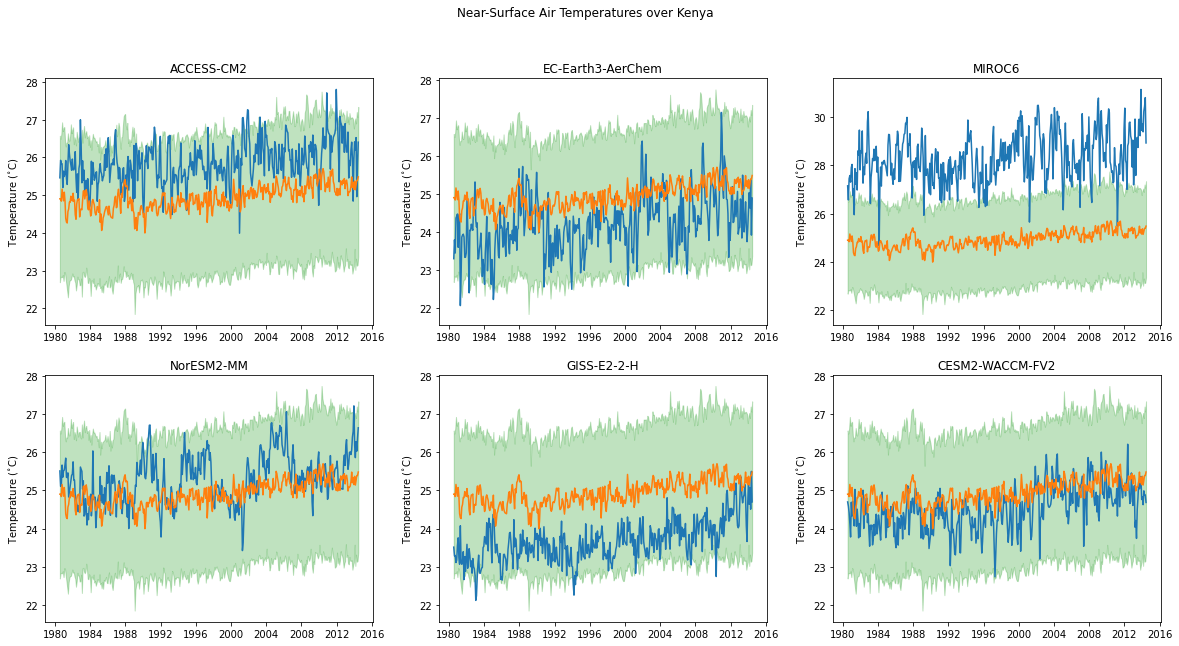

In [32]:
####KENYA####
kenya = geodf[geodf["NAME"]=="Kenya"]["geometry"]
kenya_tasks = {key:clip(value,kenya,crs) for key,value in clipped_models.items()}
kenya_clipped = dask.compute(kenya_tasks)[0]


timeseries_kenya = {key:value.mean(["lat","lon"])-273.15 for key,value in kenya_clipped.items()}
timeseries_kenya[list(timeseries_kenya.keys())[-1]] += 273.15

stationary_kenya0 = seasonal_decompose(timeseries_kenya[keys[0]]["tas"].values,period=12)
stationary_kenya1 = seasonal_decompose(timeseries_kenya[keys[1]]["tas"].values,period=12)
stationary_kenya2 = seasonal_decompose(timeseries_kenya[keys[2]]["tas"].values,period=12)
stationary_kenya3 = seasonal_decompose(timeseries_kenya[keys[3]]["tas"].values,period=12)
stationary_kenya4 = seasonal_decompose(timeseries_kenya[keys[4]]["tas"].values,period=12)
stationary_kenya5 = seasonal_decompose(timeseries_kenya[keys[5]]["tas"].values,period=12)
stationary_kenya6 = seasonal_decompose(timeseries_kenya[keys[6]]["tas"].values,period=12) # observations
stationary_kenya7 = seasonal_decompose(timeseries_kenya[keys[6]]["Q2.5"].values,period=12)
stationary_kenya8 = seasonal_decompose(timeseries_kenya[keys[6]]["Q97.5"].values,period=12)

fig, axis = plt.subplots(2,3,figsize=(20,10))
keys = list(timeseries_kenya.keys())
labels = [re.findall(r"[^\.]*",key)[6] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary_kenya0.trend+stationary_kenya0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary_kenya1.trend+stationary_kenya1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary_kenya2.trend+stationary_kenya2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary_kenya3.trend+stationary_kenya3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary_kenya4.trend+stationary_kenya4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary_kenya5.trend+stationary_kenya5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary_kenya6.trend+stationary_kenya6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary_kenya7.trend+stationary_kenya7.resid,stationary_kenya8.trend+stationary_kenya8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over Kenya")

Text(0.5, 0.98, 'Near-Surface Air Temperatures over Tanzania')

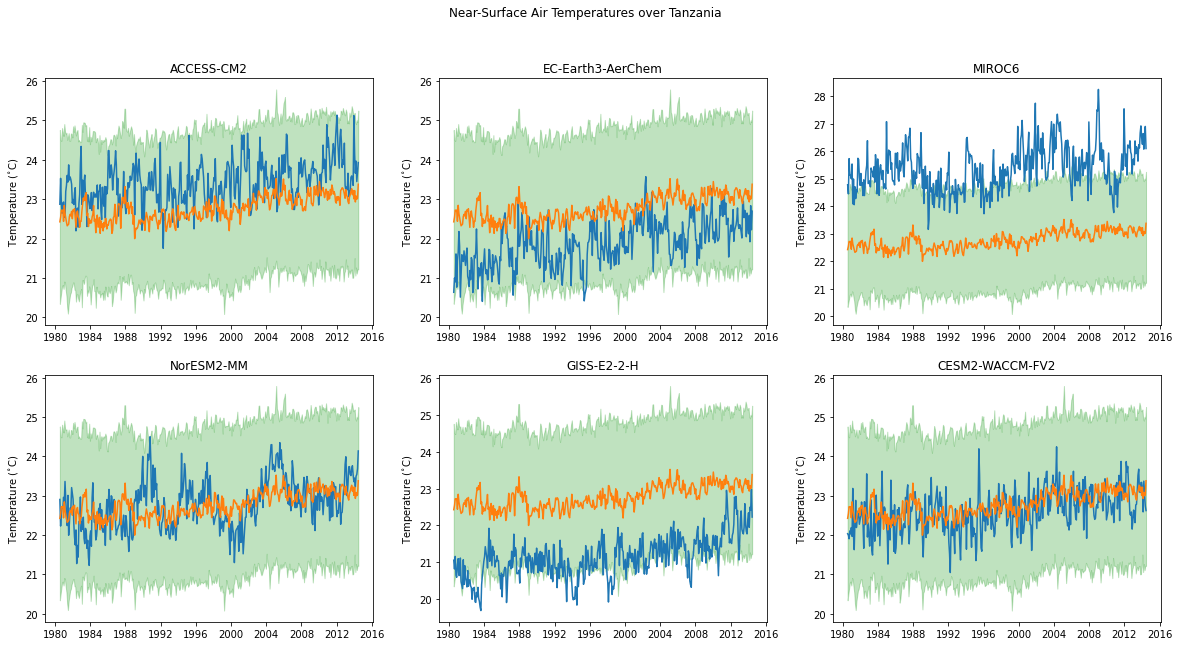

In [33]:
####TANZANIA####
tanzania = geodf[geodf["NAME"]=="Tanzania"]["geometry"]
tanzania_tasks = {key:clip(value,tanzania,crs) for key,value in clipped_models.items()}
tanzania_clipped = dask.compute(tanzania_tasks)[0]


timeseries_tanzania = {key:value.mean(["lat","lon"])-273.15 for key,value in tanzania_clipped.items()}
timeseries_tanzania[list(timeseries_tanzania.keys())[-1]] += 273.15

stationary_tanzania0 = seasonal_decompose(timeseries_tanzania[keys[0]]["tas"].values,period=12)
stationary_tanzania1 = seasonal_decompose(timeseries_tanzania[keys[1]]["tas"].values,period=12)
stationary_tanzania2 = seasonal_decompose(timeseries_tanzania[keys[2]]["tas"].values,period=12)
stationary_tanzania3 = seasonal_decompose(timeseries_tanzania[keys[3]]["tas"].values,period=12)
stationary_tanzania4 = seasonal_decompose(timeseries_tanzania[keys[4]]["tas"].values,period=12)
stationary_tanzania5 = seasonal_decompose(timeseries_tanzania[keys[5]]["tas"].values,period=12)
stationary_tanzania6 = seasonal_decompose(timeseries_tanzania[keys[6]]["tas"].values,period=12) # observations
stationary_tanzania7 = seasonal_decompose(timeseries_tanzania[keys[6]]["Q2.5"].values,period=12)
stationary_tanzania8 = seasonal_decompose(timeseries_tanzania[keys[6]]["Q97.5"].values,period=12)

fig, axis = plt.subplots(2,3,figsize=(20,10))
keys = list(timeseries_tanzania.keys())
labels = [re.findall(r"[^\.]*",key)[6] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary_tanzania0.trend+stationary_tanzania0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary_tanzania1.trend+stationary_tanzania1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary_tanzania2.trend+stationary_tanzania2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary_tanzania3.trend+stationary_tanzania3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary_tanzania4.trend+stationary_tanzania4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary_tanzania5.trend+stationary_tanzania5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary_tanzania6.trend+stationary_tanzania6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary_tanzania7.trend+stationary_tanzania7.resid,stationary_tanzania8.trend+stationary_tanzania8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over Tanzania")

Text(0.5, 0.98, 'Near-Surface Air Temperatures over South Africa')

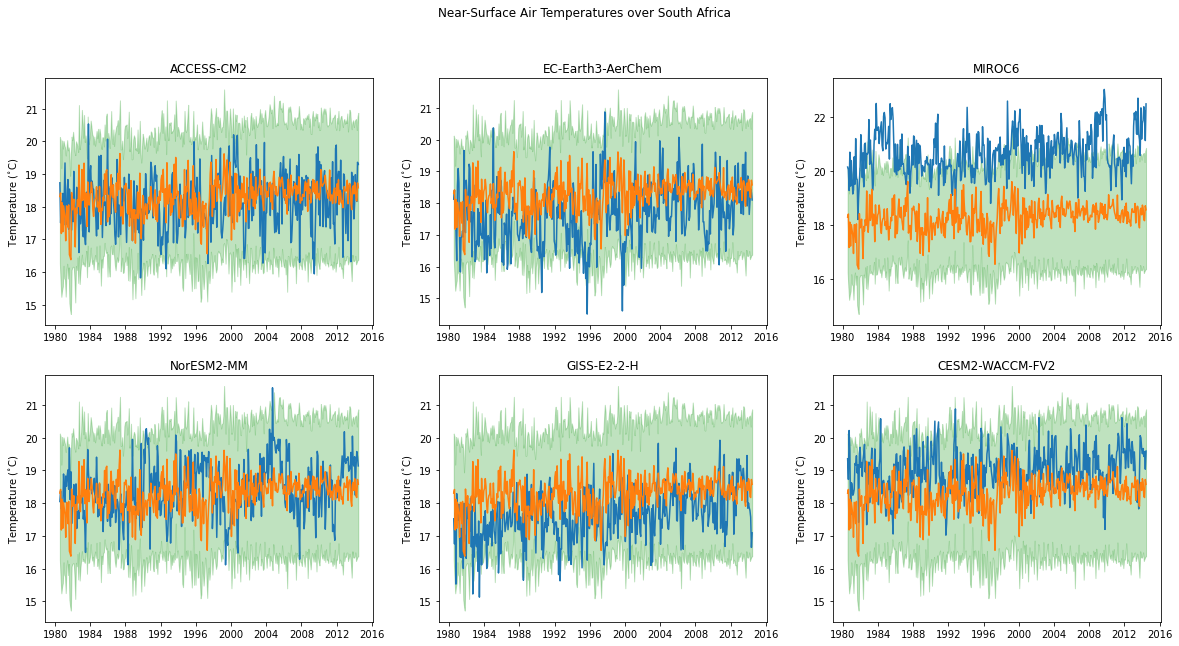

In [34]:
####SOUTH AFRICA####
south_africa = geodf[geodf["NAME"]=="South Africa"]["geometry"]
south_africa_tasks = {key:clip(value,south_africa,crs) for key,value in clipped_models.items()}
south_africa_clipped = dask.compute(south_africa_tasks)[0]


timeseries_south_africa = {key:value.mean(["lat","lon"])-273.15 for key,value in south_africa_clipped.items()}
timeseries_south_africa[list(timeseries_south_africa.keys())[-1]] += 273.15

stationary_south_africa0 = seasonal_decompose(timeseries_south_africa[keys[0]]["tas"].values,period=12)
stationary_south_africa1 = seasonal_decompose(timeseries_south_africa[keys[1]]["tas"].values,period=12)
stationary_south_africa2 = seasonal_decompose(timeseries_south_africa[keys[2]]["tas"].values,period=12)
stationary_south_africa3 = seasonal_decompose(timeseries_south_africa[keys[3]]["tas"].values,period=12)
stationary_south_africa4 = seasonal_decompose(timeseries_south_africa[keys[4]]["tas"].values,period=12)
stationary_south_africa5 = seasonal_decompose(timeseries_south_africa[keys[5]]["tas"].values,period=12)
stationary_south_africa6 = seasonal_decompose(timeseries_south_africa[keys[6]]["tas"].values,period=12) # observations
stationary_south_africa7 = seasonal_decompose(timeseries_south_africa[keys[6]]["Q2.5"].values,period=12)
stationary_south_africa8 = seasonal_decompose(timeseries_south_africa[keys[6]]["Q97.5"].values,period=12)

fig, axis = plt.subplots(2,3,figsize=(20,10))
keys = list(timeseries_south_africa.keys())
labels = [re.findall(r"[^\.]*",key)[6] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary_south_africa0.trend+stationary_south_africa0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary_south_africa1.trend+stationary_south_africa1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary_south_africa2.trend+stationary_south_africa2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary_south_africa3.trend+stationary_south_africa3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary_south_africa4.trend+stationary_south_africa4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary_south_africa5.trend+stationary_south_africa5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary_south_africa6.trend+stationary_south_africa6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary_south_africa7.trend+stationary_south_africa7.resid,stationary_south_africa8.trend+stationary_south_africa8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over South Africa")

Text(0.5, 0.98, 'Near-Surface Air Temperatures over Madagascar')

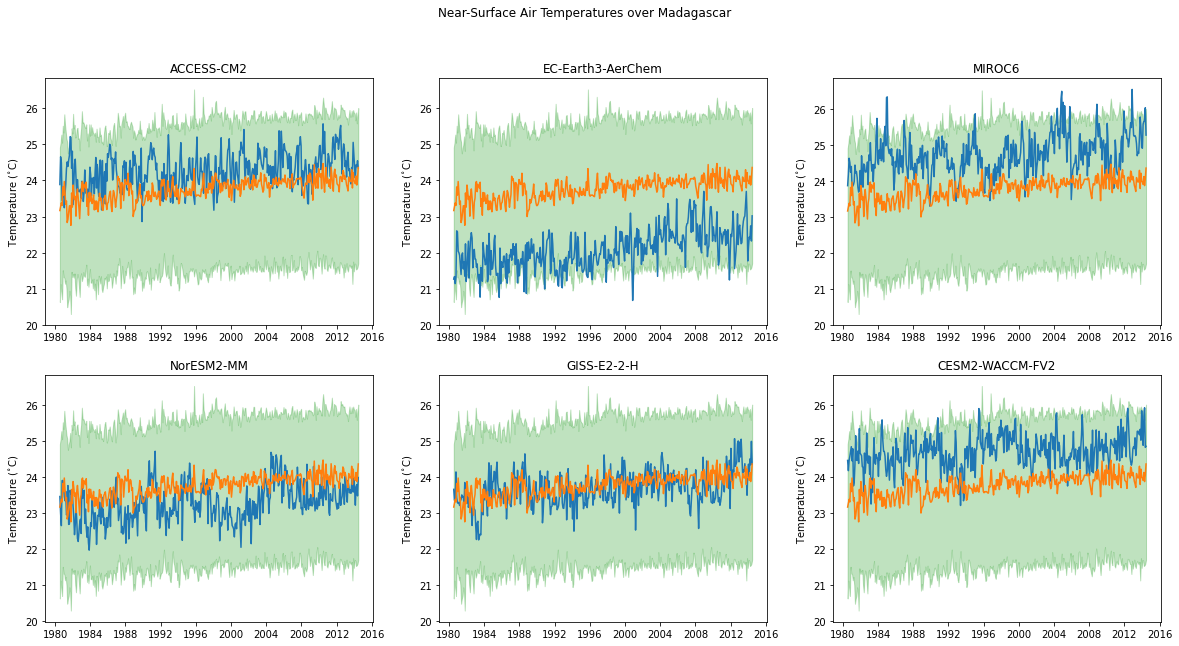

In [35]:
####MADAGASCAR####
madagascar = geodf[geodf["NAME"]=="Madagascar"]["geometry"]
madagascar_tasks = {key:clip(value,madagascar,crs) for key,value in clipped_models.items()}
madagascar_clipped = dask.compute(madagascar_tasks)[0]


timeseries_madagascar = {key:value.mean(["lat","lon"])-273.15 for key,value in madagascar_clipped.items()}
timeseries_madagascar[list(timeseries_madagascar.keys())[-1]] += 273.15

stationary_madagascar0 = seasonal_decompose(timeseries_madagascar[keys[0]]["tas"].values,period=12)
stationary_madagascar1 = seasonal_decompose(timeseries_madagascar[keys[1]]["tas"].values,period=12)
stationary_madagascar2 = seasonal_decompose(timeseries_madagascar[keys[2]]["tas"].values,period=12)
stationary_madagascar3 = seasonal_decompose(timeseries_madagascar[keys[3]]["tas"].values,period=12)
stationary_madagascar4 = seasonal_decompose(timeseries_madagascar[keys[4]]["tas"].values,period=12)
stationary_madagascar5 = seasonal_decompose(timeseries_madagascar[keys[5]]["tas"].values,period=12)
stationary_madagascar6 = seasonal_decompose(timeseries_madagascar[keys[6]]["tas"].values,period=12) # observations
stationary_madagascar7 = seasonal_decompose(timeseries_madagascar[keys[6]]["Q2.5"].values,period=12)
stationary_madagascar8 = seasonal_decompose(timeseries_madagascar[keys[6]]["Q97.5"].values,period=12)

fig, axis = plt.subplots(2,3,figsize=(20,10))
keys = list(timeseries_madagascar.keys())
labels = [re.findall(r"[^\.]*",key)[6] for key in keys[:-1]]

axis[0,0].set_title(labels[0])
axis[0,0].plot(timeseries[keys[0]].time,stationary_madagascar0.trend+stationary_madagascar0.resid)
axis[0,0].plot(timeseries[keys[0]].time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[0,0].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[0,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,1].set_title(labels[1])
axis[0,1].plot(timeseries[keys[1]].time,stationary_madagascar1.trend+stationary_madagascar1.resid)
axis[0,1].plot(timeseries[keys[1]].time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[0,1].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[0,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[0,2].set_title(labels[2])
axis[0,2].plot(timeseries[keys[2]].time,stationary_madagascar2.trend+stationary_madagascar2.resid)
axis[0,2].plot(timeseries[keys[2]].time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[0,2].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[0,2].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,0].set_title(labels[3])
axis[1,0].plot(timeseries[keys[3]].time,stationary_madagascar3.trend+stationary_madagascar3.resid)
axis[1,0].plot(timeseries[keys[3]].time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[1,0].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[1,0].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,1].set_title(labels[4])
axis[1,1].plot(timeseries[keys[4]].time,stationary_madagascar4.trend+stationary_madagascar4.resid)
axis[1,1].plot(timeseries[keys[4]].time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[1,1].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[1,1].set_ylabel(r"Temperature ($^{\circ}$C)")

axis[1,2].set_title(labels[5])
axis[1,2].plot(timeseries[keys[5]].time,stationary_madagascar5.trend+stationary_madagascar5.resid)
axis[1,2].plot(timeseries[keys[5]].time.time,stationary_madagascar6.trend+stationary_madagascar6.resid)
axis[1,2].fill_between(timeseries[keys[5]].time,stationary_madagascar7.trend+stationary_madagascar7.resid,stationary_madagascar8.trend+stationary_madagascar8.resid,color="tab:green",alpha=0.3)
axis[1,2].set_ylabel(r"Temperature ($^{\circ}$C)")

fig.suptitle("Near-Surface Air Temperatures over Madagascar")